### Logistic regression and Maximum Likelihood Exstimation

In [90]:
import pandas as pd

df = pd.read_csv("../Data/Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


#### Exercise
For this exercise, we will choose the column 'Heart Disease' as our response variable. The classification is a binary problem, 'present' och 'absent'. 

In this dataset, there are several categorical variables. The dataset is from Kaggle: https://www.kaggle.com/datasets/neurocipher/heartdisease

Investigate the following imports and use them to solve the exercise.

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

a) One-hot encode categorical data in the dataframe. The response, "Heart Disease", also need encoding. Use pandas for these encodings for convenience, or code them manually if you're up for it! Many columns in this problem are categorical.

In [92]:
df = pd.get_dummies(df, columns=["Heart Disease"], drop_first=True)
df = pd.get_dummies(df, columns=["Sex", "Number of vessels fluro", "Thallium", "FBS over 120", "Chest pain type", "EKG results", "Exercise angina", "Slope of ST"], drop_first=False)
df.head()

,Age,BP,Cholesterol,Max HR,ST depression,Heart Disease_Presence,Sex_0,Sex_1,Number of vessels fluro_0,Number of vessels fluro_1,...,Chest pain type_3,Chest pain type_4,EKG results_0,EKG results_1,EKG results_2,Exercise angina_0,Exercise angina_1,Slope of ST_1,Slope of ST_2,Slope of ST_3
0,70,130,322,109,2.4,True,False,True,False,False,...,False,True,False,False,True,True,False,False,True,False
1,67,115,564,160,1.6,False,True,False,True,False,...,True,False,False,False,True,True,False,False,True,False
2,57,124,261,141,0.3,True,False,True,True,False,...,False,False,True,False,False,True,False,True,False,False
3,64,128,263,105,0.2,False,False,True,False,True,...,False,True,True,False,False,False,True,False,True,False
4,74,120,269,121,0.2,False,True,False,False,True,...,False,False,False,False,True,False,True,True,False,False


b) Create a train/test split. We won't use a validation set for this problem, since we aren't refining the results anyhow.

c) Scale and center the data. Use StandardScaler from sklearn, or use the _standardization_ statistic $\frac{x-\bar{x}}{S}$ on the <em>training</em>data. Use the _same_ values to standardize the test data (note that this may give values outside the standardized range: this is the entire point). For sklearn this means using `fit_transform` on the training data but _only_ `transform` on the test data. If you calculate yourself, $\bar{x}$ and $S$ are calculated on the trainingdata and then applied also to the testdata -- don't recalculate the standardization statistic for the testdata, but use the same values as calculated on the trainingdata for $\bar{x}$ and $S$. 

In [93]:
X, y = df.drop("Heart Disease_Presence", axis=1), df["Heart Disease_Presence"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

d) Use LogisticRegression from sklearn and fit a regression to the scaled training data.

In [94]:
model = LogisticRegression(penalty='l2')
model.fit(scaled_X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


e) Investigate the below imports and use them to produce a Confusion Matrix and a classification report.

              precision    recall  f1-score   support

       False       0.92      0.90      0.91        52
        True       0.87      0.89      0.88        38

    accuracy                           0.90        90
   macro avg       0.90      0.90      0.90        90
weighted avg       0.90      0.90      0.90        90



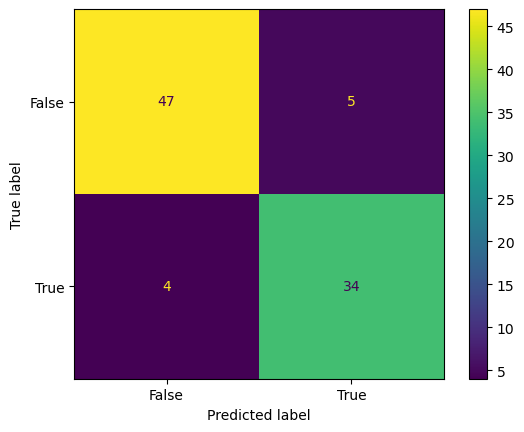

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = model.predict(scaled_X_test)

report = classification_report(y_test, y_pred)
print(report)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
displ = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
displ.plot()